# 🥛 Data Preprocessing — Milk Quality Prediction
**Dataset:** milknew.csv (Kaggle: cpluzshrijayan/milkquality)  
**Metode:** K-Means Clustering + Logistic Regression + Naïve Bayes  
**Tahap:** Data Preprocessing


In [1]:
# ── Import Library ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Style plot
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print("✅ Semua library berhasil diimport!")


✅ Semua library berhasil diimport!


## 1. Load Dataset

In [2]:
df = pd.read_csv('milknew.csv')

print(f"Shape  : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"Kolom  : {list(df.columns)}")
print()
df.head(10)


Shape  : 1059 baris × 8 kolom
Kolom  : ['pH', 'Temprature', 'Taste', 'Odor', 'Fat ', 'Turbidity', 'Colour', 'Grade']



,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,high
1,6.6,36,0,1,0,1,253,high
2,8.5,70,1,1,1,1,246,low
3,9.5,34,1,1,0,1,255,low
4,6.6,37,0,0,0,0,255,medium
5,6.6,37,1,1,1,1,255,high
6,5.5,45,1,0,1,1,250,low
7,4.5,60,0,1,1,1,250,low
8,8.1,66,1,0,1,1,255,low
9,6.7,45,1,1,0,0,247,medium


In [3]:
print("=== Info DataFrame ===")
df.info()


=== Info DataFrame ===
<class 'pandas.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pH          1059 non-null   float64
 1   Temprature  1059 non-null   int64  
 2   Taste       1059 non-null   int64  
 3   Odor        1059 non-null   int64  
 4   Fat         1059 non-null   int64  
 5   Turbidity   1059 non-null   int64  
 6   Colour      1059 non-null   int64  
 7   Grade       1059 non-null   str    
dtypes: float64(1), int64(6), str(1)
memory usage: 70.8 KB


In [4]:
print("=== Statistik Deskriptif ===")
df.describe().round(3)


=== Statistik Deskriptif ===


,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour
count,1059.00,1059.000,1059.000,1059.000,1059.000,1059.000,1059.000
mean,6.63,44.227,0.547,0.432,0.671,0.491,251.840
std,1.40,10.098,0.498,0.496,0.470,0.500,4.307
min,3.00,34.000,0.000,0.000,0.000,0.000,240.000
25%,6.50,38.000,0.000,0.000,0.000,0.000,250.000
50%,6.70,41.000,1.000,0.000,1.000,0.000,255.000
75%,6.80,45.000,1.000,1.000,1.000,1.000,255.000
max,9.50,90.000,1.000,1.000,1.000,1.000,255.000


## 2. Pemeriksaan Missing Values

     Kolom  Jumlah Missing  Persentase (%)
        pH               0             0.0
Temprature               0             0.0
     Taste               0             0.0
      Odor               0             0.0
      Fat                0             0.0
 Turbidity               0             0.0
    Colour               0             0.0
     Grade               0             0.0


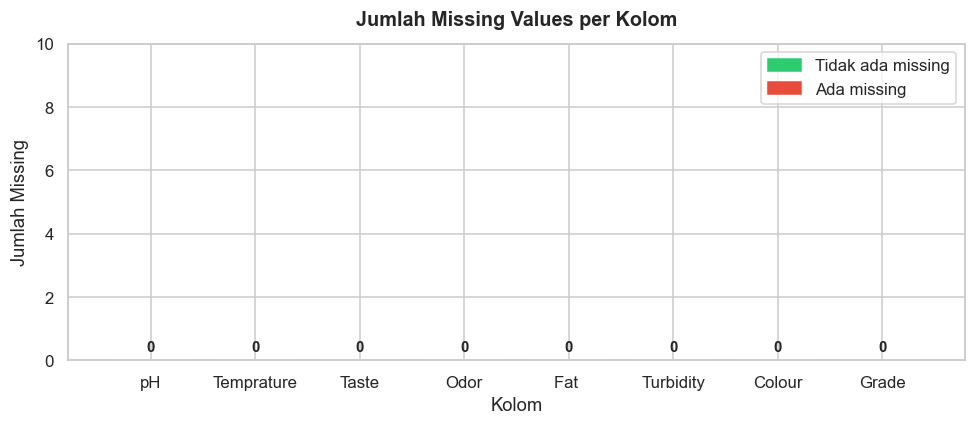

✅ Tidak ditemukan missing value.


In [5]:
missing = df.isnull().sum().reset_index()
missing.columns = ['Kolom', 'Jumlah Missing']
missing['Persentase (%)'] = (missing['Jumlah Missing'] / len(df) * 100).round(2)
print(missing.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71' if v == 0 else '#e74c3c' for v in missing['Jumlah Missing']]
bars = ax.bar(missing['Kolom'], missing['Jumlah Missing'], color=colors, edgecolor='white', linewidth=1.2)
ax.set_title('Jumlah Missing Values per Kolom', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Kolom')
ax.set_ylabel('Jumlah Missing')
ax.set_ylim(0, max(missing['Jumlah Missing'].max() + 5, 10))
for bar, val in zip(bars, missing['Jumlah Missing']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)
patch_ok  = mpatches.Patch(color='#2ecc71', label='Tidak ada missing')
patch_err = mpatches.Patch(color='#e74c3c', label='Ada missing')
ax.legend(handles=[patch_ok, patch_err], loc='upper right')
plt.tight_layout()
plt.savefig('plot_missing_values.png', bbox_inches='tight')
plt.show()
print("✅ Tidak ditemukan missing value.")


## 3. Pemeriksaan & Penghapusan Duplikasi

Jumlah baris sebelum  : 1059
Jumlah baris duplikat : 976
Jumlah baris sesudah  : 83


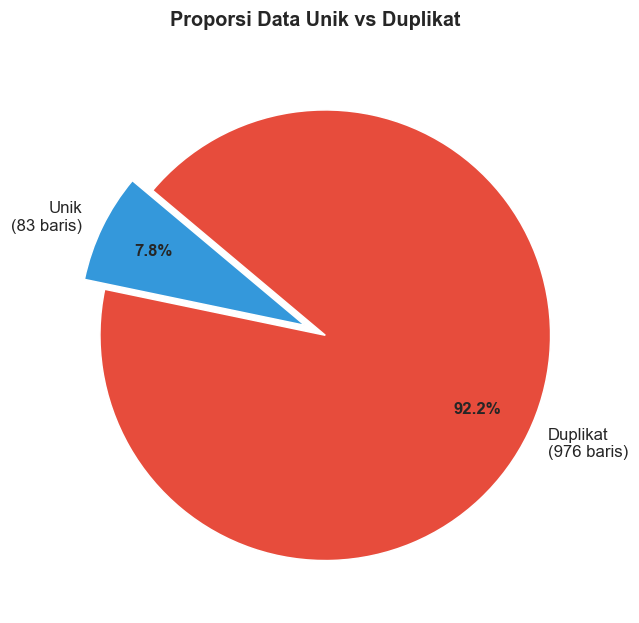


✅ Duplikat berhasil dihapus. Shape sekarang: (83, 8)


In [6]:
n_before  = len(df)
n_dup     = df.duplicated().sum()
n_after   = n_before - n_dup

print(f"Jumlah baris sebelum  : {n_before}")
print(f"Jumlah baris duplikat : {n_dup}")
print(f"Jumlah baris sesudah  : {n_after}")

# Pie chart
fig, ax = plt.subplots(figsize=(6, 6))
sizes  = [n_after, n_dup]
labels = [f'Unik\n({n_after} baris)', f'Duplikat\n({n_dup} baris)']
colors = ['#3498db', '#e74c3c']
explode = (0.05, 0.05)
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, explode=explode,
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 11}, pctdistance=0.75)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Proporsi Data Unik vs Duplikat', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_duplikasi.png', bbox_inches='tight')
plt.show()

# Drop duplikat
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"\n✅ Duplikat berhasil dihapus. Shape sekarang: {df_clean.shape}")


## 4. Distribusi Kelas (Grade)

 Grade  Sebelum Dedup  Sesudah Dedup  Pct Sebelum  Pct Sesudah
   low            429             26         40.5         31.3
medium            374             34         35.3         41.0
  high            256             23         24.2         27.7


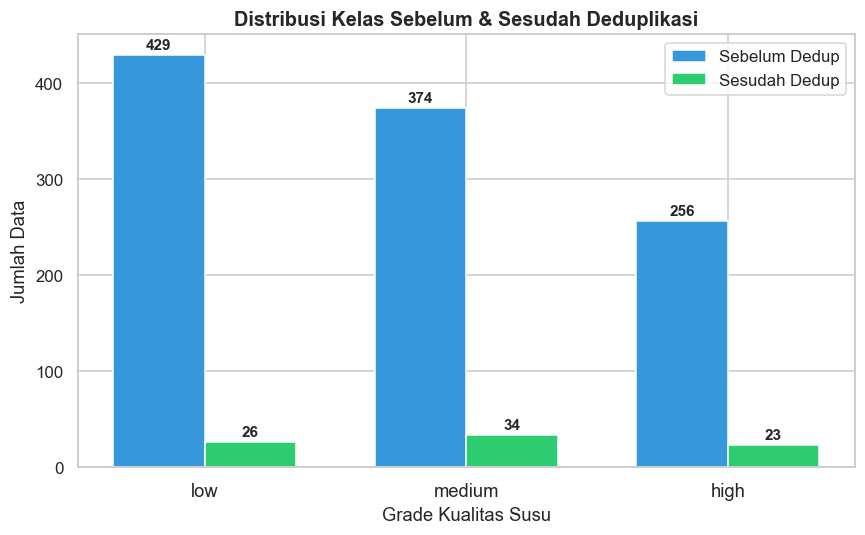

In [7]:
grade_before = df['Grade'].value_counts().reset_index()
grade_before.columns = ['Grade', 'Sebelum Dedup']
grade_after  = df_clean['Grade'].value_counts().reset_index()
grade_after.columns  = ['Grade', 'Sesudah Dedup']
dist = grade_before.merge(grade_after, on='Grade')
dist['Pct Sebelum'] = (dist['Sebelum Dedup'] / dist['Sebelum Dedup'].sum() * 100).round(1)
dist['Pct Sesudah'] = (dist['Sesudah Dedup'] / dist['Sesudah Dedup'].sum() * 100).round(1)
print(dist.to_string(index=False))

# Side-by-side bar
x     = np.arange(len(dist))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, dist['Sebelum Dedup'], width, label='Sebelum Dedup',
            color='#3498db', edgecolor='white')
b2 = ax.bar(x + width/2, dist['Sesudah Dedup'], width, label='Sesudah Dedup',
            color='#2ecc71', edgecolor='white')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(bar.get_height())), ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(dist['Grade'], fontsize=12)
ax.set_xlabel('Grade Kualitas Susu')
ax.set_ylabel('Jumlah Data')
ax.set_title('Distribusi Kelas Sebelum & Sesudah Deduplikasi', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_distribusi_grade.png', bbox_inches='tight')
plt.show()


## 5. Deteksi Outlier (Metode IQR)

     Kolom    Q1    Q3  IQR  Lower Bound  Upper Bound  Jumlah Outlier       Keputusan
        pH   6.5   6.8  0.3         6.05         7.25              17 Dipertahankan ✅
Temprature  38.0  45.0  7.0        27.50        55.50               6 Dipertahankan ✅
    Colour 247.0 255.0  8.0       235.00       267.00               0 Dipertahankan ✅


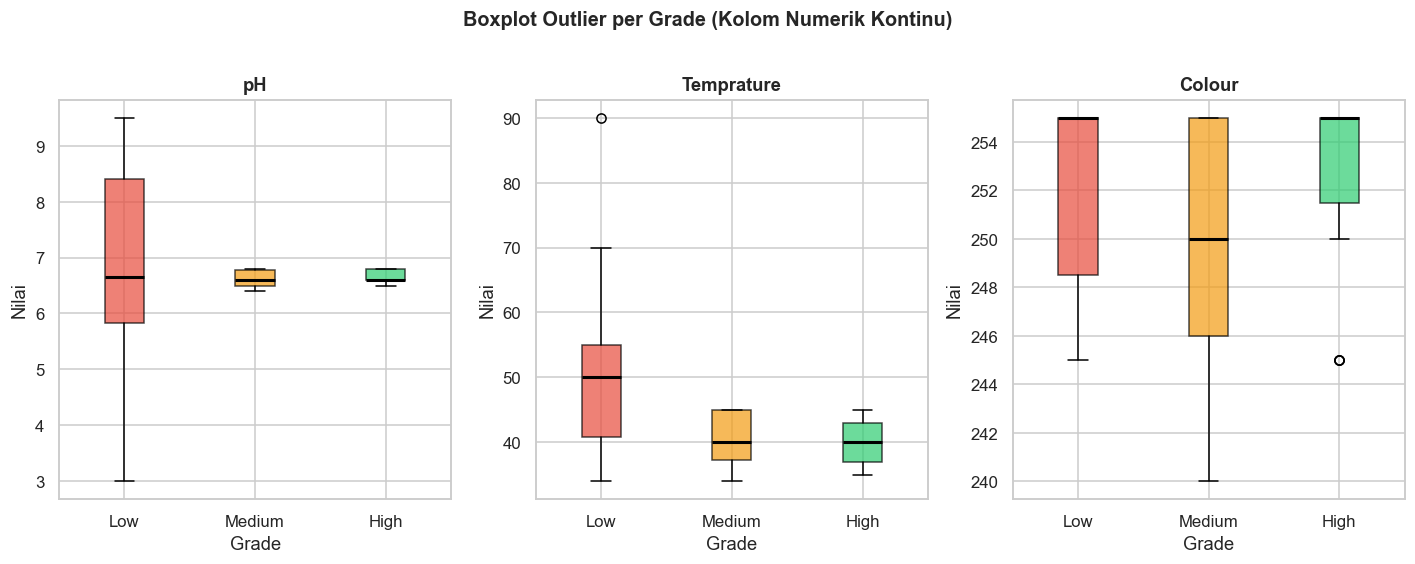


📌 Outlier DIPERTAHANKAN — nilai ekstrem pH/Temprature berkaitan dengan susu kualitas rendah (domain-valid).


In [8]:
# Rename kolom 'Fat ' (ada trailing space)
df_clean = df_clean.rename(columns={'Fat ': 'Fat'})

numeric_cols = ['pH', 'Temprature', 'Colour']

# Tabel ringkasan outlier
rows = []
for col in numeric_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lb) | (df_clean[col] > ub)).sum()
    rows.append({'Kolom': col, 'Q1': Q1, 'Q3': Q3, 'IQR': round(IQR,2),
                 'Lower Bound': round(lb,2), 'Upper Bound': round(ub,2),
                 'Jumlah Outlier': n_out, 'Keputusan': 'Dipertahankan ✅'})
print(pd.DataFrame(rows).to_string(index=False))

# Boxplot
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(13, 5))
palette = ['#9b59b6', '#e67e22', '#1abc9c']
for ax, col, color in zip(axes, numeric_cols, palette):
    data_by_grade = [df_clean[df_clean['Grade']==g][col].values for g in ['low','medium','high']]
    bp = ax.boxplot(data_by_grade, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], ['#e74c3c','#f39c12','#2ecc71']):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Low','Medium','High'])
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Grade')
    ax.set_ylabel('Nilai')
fig.suptitle('Boxplot Outlier per Grade (Kolom Numerik Kontinu)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_boxplot_outlier.png', bbox_inches='tight')
plt.show()
print("\n📌 Outlier DIPERTAHANKAN — nilai ekstrem pH/Temprature berkaitan dengan susu kualitas rendah (domain-valid).")


## 6. Encoding Label Target (Grade)

Mapping Label Encoding:
  high     → 0
  low      → 1
  medium   → 2

 Grade  Grade_encoded  count
  high              0     23
   low              1     26
medium              2     34


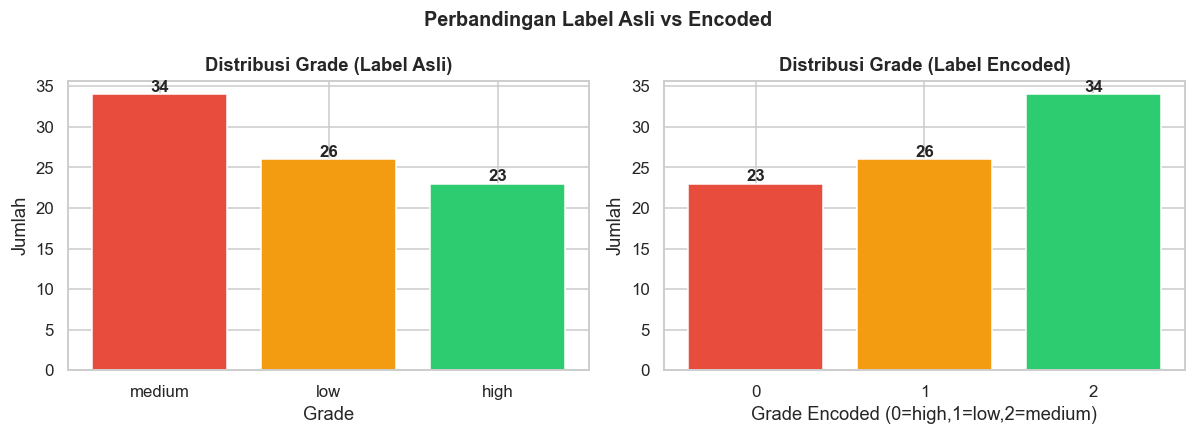

In [9]:
le = LabelEncoder()
df_clean['Grade_encoded'] = le.fit_transform(df_clean['Grade'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping Label Encoding:")
for k, v in mapping.items():
    print(f"  {k:8s} → {v}")
print()
print(df_clean[['Grade','Grade_encoded']].value_counts().reset_index().sort_values('Grade').to_string(index=False))

# Bar chart hasil encoding
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
grade_counts = df_clean['Grade'].value_counts()
grade_enc    = df_clean['Grade_encoded'].value_counts().sort_index()
colors_bar   = ['#e74c3c', '#f39c12', '#2ecc71']

axes[0].bar(grade_counts.index, grade_counts.values, color=colors_bar, edgecolor='white')
axes[0].set_title('Distribusi Grade (Label Asli)', fontweight='bold')
axes[0].set_xlabel('Grade'); axes[0].set_ylabel('Jumlah')
for i, (lbl, val) in enumerate(grade_counts.items()):
    axes[0].text(i, val+0.3, str(val), ha='center', fontweight='bold')

axes[1].bar([str(k) for k in grade_enc.index], grade_enc.values,
            color=colors_bar, edgecolor='white')
axes[1].set_title('Distribusi Grade (Label Encoded)', fontweight='bold')
axes[1].set_xlabel('Grade Encoded (0=high,1=low,2=medium)')
axes[1].set_ylabel('Jumlah')
for i, val in enumerate(grade_enc.values):
    axes[1].text(i, val+0.3, str(val), ha='center', fontweight='bold')

plt.suptitle('Perbandingan Label Asli vs Encoded', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_encoding.png', bbox_inches='tight')
plt.show()


## 7. Feature Scaling

In [ ]:
features = ['pH','Temprature','Taste','Odor','Fat','Turbidity','Colour']

# MinMax Scaler
scaler_mm  = MinMaxScaler()
df_minmax  = df_clean.copy()
df_minmax[features] = scaler_mm.fit_transform(df_clean[features])

# Standard Scaler
scaler_std  = StandardScaler()
df_standard = df_clean.copy()
df_standard[features] = scaler_std.fit_transform(df_clean[features])

print("=== Contoh data setelah MinMaxScaler (5 baris) ===")
print(df_minmax[features].head().round(4).to_string())
print()
print("=== Contoh data setelah StandardScaler (5 baris) ===")
print(df_standard[features].head().round(4).to_string())

# Visualisasi distribusi sebelum vs sesudah scaling (pilih 3 kolom)
viz_cols  = ['pH', 'Temprature', 'Colour']
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, col in enumerate(viz_cols):
    # Before
    axes[i][0].hist(df_clean[col], bins=15, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i][0].set_title(f'{col} — Original', fontweight='bold')
    axes[i][0].set_ylabel('Frekuensi')
    # MinMax
    axes[i][1].hist(df_minmax[col], bins=15, color='#2ecc71', edgecolor='white', alpha=0.85)
    axes[i][1].set_title(f'{col} — MinMaxScaler', fontweight='bold')
    # Standard
    axes[i][2].hist(df_standard[col], bins=15, color='#e67e22', edgecolor='white', alpha=0.85)
    axes[i][2].set_title(f'{col} — StandardScaler', fontweight='bold')

fig.suptitle('Distribusi Fitur: Original vs MinMax vs Standard Scaling',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_scaling_distribusi.png', bbox_inches='tight')
plt.show()
print("\n✅ MinMaxScaler → untuk K-Means & Logistic Regression")
print("✅ StandardScaler → untuk Gaussian Naïve Bayes")


=== Contoh data setelah MinMaxScaler (5 baris) ===
       pH  Temprature  Taste  Odor  Fat  Turbidity  Colour
0  0.5538      0.0179    1.0   0.0  1.0        0.0  0.9333
1  0.5538      0.0357    0.0   1.0  0.0        1.0  0.8667
2  0.8462      0.6429    1.0   1.0  1.0        1.0  0.4000
3  1.0000      0.0000    1.0   1.0  0.0        1.0  1.0000
4  0.5538      0.0536    0.0   0.0  0.0        0.0  1.0000

=== Contoh data setelah StandardScaler (5 baris) ===
       pH  Temprature   Taste    Odor     Fat  Turbidity  Colour
0 -0.0700     -0.9331  1.0121 -0.8124  0.8124    -0.8752  0.5906
1 -0.0700     -0.8258 -0.9880  1.2309 -1.2309     1.1426  0.3708
2  1.8670      2.8213  1.0121  1.2309  0.8124     1.1426 -1.1679
3  2.8865     -1.0404  1.0121  1.2309 -1.2309     1.1426  0.8104
4 -0.0700     -0.7186 -0.9880 -0.8124 -1.2309    -0.8752  0.8104


## 8. Analisis Korelasi Fitur

In [ ]:
corr_matrix = df_clean[features + ['Grade_encoded']].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(10, 7))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 10})
ax.set_title('Heatmap Korelasi Antar Fitur & Target', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot_heatmap_korelasi.png', bbox_inches='tight')
plt.show()

# Bar korelasi vs target
corr_target = corr_matrix['Grade_encoded'].drop('Grade_encoded').sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
colors_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_target]
bars = ax.barh(corr_target.index, corr_target.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=10, fontweight='bold')
ax.set_title('Korelasi Fitur terhadap Grade (Target)', fontsize=13, fontweight='bold')
ax.set_xlabel('Nilai Korelasi')
plt.tight_layout()
plt.savefig('plot_korelasi_target.png', bbox_inches='tight')
plt.show()
print("\n📌 Fat, Odor, dan Turbidity adalah fitur paling berpengaruh terhadap kualitas susu.")


## 9. Simpan Hasil Preprocessing

In [ ]:
# Simpan semua versi dataset
df_clean.to_csv('milknew_clean.csv', index=False)
df_minmax.to_csv('milknew_minmax.csv', index=False)
df_standard.to_csv('milknew_standard.csv', index=False)

print("✅ File berhasil disimpan:")
print("   • milknew_clean.csv    — data bersih (tanpa scaling)")
print("   • milknew_minmax.csv   — MinMaxScaler (K-Means & Logistic Regression)")
print("   • milknew_standard.csv — StandardScaler (Naïve Bayes)")
print(f"\nShape final: {df_clean.shape}")
print(f"Kolom: {list(df_clean.columns)}")


## 10. Ringkasan Preprocessing

| Tahap | Aksi | Hasil |
|---|---|---|
| **Load Data** | pd.read_csv | 1.059 baris × 8 kolom |
| **Missing Values** | Pemeriksaan | ✅ Tidak ada missing value |
| **Duplikasi** | drop_duplicates() | 1.059 → **83 baris** |
| **Outlier** | IQR detection | Dipertahankan (domain-valid) |
| **Rename Kolom** | `Fat ` → `Fat` | Trailing space dihapus |
| **Label Encoding** | LabelEncoder pada Grade | high=0, low=1, medium=2 |
| **MinMax Scaling** | MinMaxScaler (0–1) | Untuk K-Means & Logistic Regression |
| **Standard Scaling** | StandardScaler (z-score) | Untuk Naïve Bayes |
| **Analisis Korelasi** | Pearson correlation | Fat & Odor paling signifikan |

> **Catatan:** 976 baris duplikat (92%) kemungkinan akibat cara pengumpulan dataset di Kaggle. Data setelah deduplikasi (83 baris) digunakan untuk pemodelan.
